In [120]:
import xtrack as xt
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt


In [121]:
# Environment and Particle Reference
env = xt.Environment()
env.set_particle_ref('electron', p0c=45.6e9)

In [122]:
# Parameters - Geometry
n_cells = 20
total_bends = n_cells * 2
# Force the angle so that total bending is exactly 2*pi
bend_angle = (2 * np.pi) / total_bends 
bend_length = 1.0
quad_length = 0.3

In [123]:
# 3. Define Elements
env.new('mb', xt.Bend, length=bend_length, angle=bend_angle)
env.new('mqf', xt.Quadrupole, length=quad_length, k1=0.02)
env.new('mqd', xt.Quadrupole, length=quad_length, k1=-0.02)
env.new('dr', xt.Drift, length=0.2)

'dr'

In [124]:
# 4. RF Cavity 
c = 299792458.0
ring_length = c/400e6
f_rev = 400e6
h = 1000 # Harmonic number
rf_freq = 400e6
# increase voltage to ensure it covers the synchrotron radiation loss
env.new('rf', xt.Cavity, voltage=5e6, frequency=rf_freq, lag=180)

'rf'

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


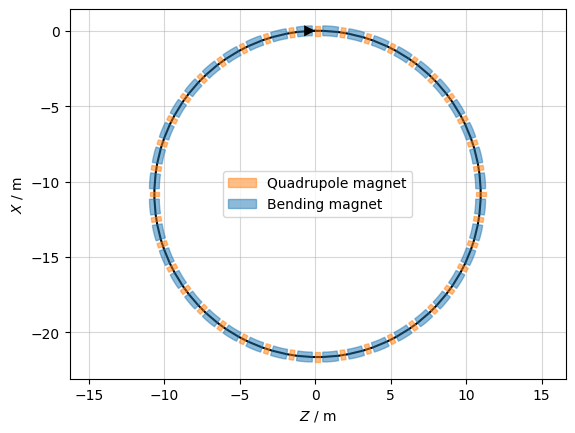

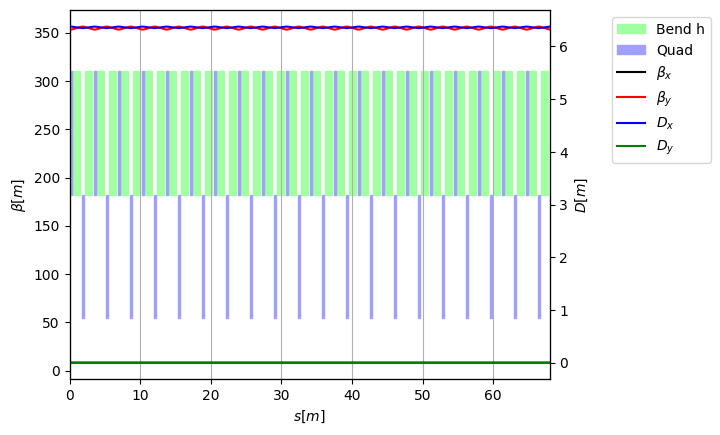


Ring circumference = 68.00000000000006 m
[0.         0.00570904 0.00951531 0.0285714  0.03240649 0.03816919
 0.04200428 0.06106037 0.06486665 0.06486665 0.07057568 0.07438196
 0.09343805 0.09727314 0.10303584 0.10687093 0.12592702 0.1297333
 0.1297333  0.13544233 0.13924861 0.1583047  0.16213979 0.16790249
 0.17173758 0.19079367 0.19459994 0.19459994 0.20030898 0.20411526
 0.22317134 0.22700643 0.23276914 0.23660423 0.25566032 0.25946659
 0.25946659 0.26517563 0.2689819  0.28803799 0.29187308 0.29763579
 0.30147088 0.32052697 0.32433324 0.32433324 0.33004228 0.33384855
 0.35290464 0.35673973 0.36250243 0.36633753 0.38539361 0.38919989
 0.38919989 0.39490893 0.3987152  0.41777129 0.42160638 0.42736908
 0.43120417 0.45026026 0.45406654 0.45406654 0.45977557 0.46358185
 0.48263794 0.48647303 0.49223573 0.49607082 0.51512691 0.51893319
 0.51893319 0.52464222 0.5284485  0.54750459 0.55133968 0.55710238
 0.56093747 0.57999356 0.58379983 0.58379983 0.58950887 0.59331514
 0.61237123 0.6162063

In [125]:
# 5. Build the Ring
cell_components = ['mqf', 'dr', 'mb', 'dr', 'mqd', 'dr', 'mb', 'dr','rf']
#place the RF cavity at the start of the full ring sequence

ring_components = (cell_components * n_cells)
ring = env.new_line(components=ring_components)
ring.survey().plot()

ring.twiss4d().plot()
plt.show()

print("\nRing circumference =", ring.get_length(), "m")

tw=ring.twiss()
print(tw['mux']) # Horizontal phase advance
print(tw['muy']) # Vertical phase advance

Text(0, 0.5, 'Qy')

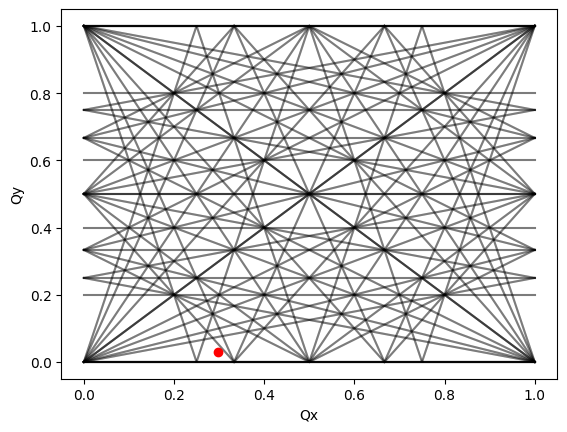

In [126]:
tw=ring.twiss()
qx=tw.qx %1
qy=tw.qy %1

N=5
x=np.linspace(0,1,1000)
for m in range(-N,N+1):
    for n in range(-N,N+1):
        if m==0 and n==0:

            continue
        order=abs(m)+abs(n)
        if order >N:
            continue
        for k in range (-N,N+1):
            if n!=0:
                y=(k-m*x)/n
                mask=(y>=0)&(y<=1)
                plt.plot(x[mask],y[mask],'k-',alpha=0.3)
plt.plot(qx,qy,'ro',label='Working Point')
plt.xlabel('Qx')
plt.ylabel('Qy')


In [127]:
ring.build_tracker()
ring.replace_all_repeated_elements()

# 7. Configure Radiation and Tapering
ring.configure_radiation(model='mean')

# 8.Twiss 6D
tw = ring.twiss(method='6d')
    
    
print("\nBaseline Results")
print(f"Circumference: {tw.s[-1]:.3f} m")
print(f"Tunes: Qx = {tw.qx:.4f}, Qy = {tw.qy:.4f}")
print(f"Energy loss/turn: {tw.eneloss_turn * 1e-6:.3f} MeV")
print(f"Chromaticity Q'x: {tw.dqx:.3f}, Q'y: {tw.dqy:.3f}")
    
# Plotting the results
tw.plot()
plt.show()

print("\nRing circumference =", ring.get_length(), "m")

The line already has an associated tracker


Could not find point within tolerance.


Warning! Need second attempt on closed orbit search


Could not find point within tolerance.




ClosedOrbitSearchError: 

In [ ]:
import xtrack as xt
import numpy as np

env = xt.Environment()
env.set_particle_ref('electron', p0c=45.6e9)

# Elements
env.new('dr', xt.Drift, length=2.0)
env.new('qf', xt.Quadrupole, length=0.3, k1=0.02)
env.new('qd', xt.Quadrupole, length=0.3, k1=-0.02)
env.new('bend', xt.Bend, length=1.0, angle=2*np.pi/40)
env.new('cav', xt.Cavity, voltage=5e6, frequency=400e6, lag=180)

cell = ('dr','qf','dr','bend','dr','qd','dr','bend','cav')
n_cells = 20
ring = env.new_line(name='toy_ring', components=cell*n_cells)
ring.build_tracker()

tw = ring.twiss(method='6d', symplectify=True)

print("Tunes: Qx, Qy, Qs =", tw.qx, tw.qy, tw.qs)

Tunes: Qx, Qy, Qs = 2.308626596606233 0.09929834337778554 0.1365981402555385


In [133]:
# ==========================================================
# WEEK 1 BASELINE ELECTRON RING (WORKING VERSION)
# 45.6 GeV with realistic bending radius
# ==========================================================

import xtrack as xt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------------------------
# 1) Create Environment and Reference Particle
# ----------------------------------------------------------

env = xt.Environment()
energy_GeV = 45.6
env.set_particle_ref('electron', p0c=energy_GeV * 1e9)

c = 299792458.0

# ----------------------------------------------------------
# 2) Geometry Parameters (REALISTIC)
# ----------------------------------------------------------

n_cells = 200                     # increase cells -> large radius
cell_length = 200.0               # meters per cell

total_bends = n_cells * 2
bend_angle = (2 * np.pi) / total_bends
bend_length = 10.0                # meters

# This gives bending radius:
rho = bend_length / bend_angle
print("Bending radius rho ≈", round(rho/1000,2), "km")

quad_length = 2.0

# Quadrupole strengths (mild focusing)
kqf = 0.005
kqd = -0.005

# ----------------------------------------------------------
# 3) Define Elements
# ----------------------------------------------------------

env.new('mb', xt.Bend, length=bend_length, angle=bend_angle)
env.new('mqf', xt.Quadrupole, length=quad_length, k1=kqf)
env.new('mqd', xt.Quadrupole, length=quad_length, k1=kqd)
env.new('dr', xt.Drift, length=cell_length/4 - quad_length/2 - bend_length/2)

# ----------------------------------------------------------
# 4) RF System
# ----------------------------------------------------------

ring_length = n_cells * cell_length
f_rev = c / ring_length
h = 10000
rf_freq = h * f_rev

rf_voltage = 100e6  # 100 MV (safe margin)

env.new('rf', xt.Cavity,
        voltage=rf_voltage,
        frequency=rf_freq,
        lag=0)

# ----------------------------------------------------------
# 5) Build Ring
# ----------------------------------------------------------

cell = env.new_line(components=[
    'mqf', 'dr', 'mb', 'dr',
    'mqd', 'dr', 'mb', 'dr'
])

ring_components = (cell_components * n_cells)
ring = env.new_line(components=['rf'] + ring_components)

ring.build_tracker()

print("\nRing circumference =", ring.get_length()/1000, "km")

# ----------------------------------------------------------
# 6) 4D Twiss (No Radiation)
# ----------------------------------------------------------

tw4 = ring.twiss(method='4d')

print("\n--- 4D OPTICS ---")
print(f"Qx = {tw4.qx:.4f}")
print(f"Qy = {tw4.qy:.4f}")
print(f"Chromaticity Q'x = {tw4.dqx:.3f}")
print(f"Chromaticity Q'y = {tw4.dqy:.3f}")

# Stability check
Mx = tw4.R_matrix[0:2,0:2]
My = tw4.R_matrix[2:4,2:4]
print("\n|Tr(Mx)| =", abs(np.trace(Mx)))
print("|Tr(My)| =", abs(np.trace(My)))

# ----------------------------------------------------------
# 7) Turn On Radiation
# ----------------------------------------------------------
ring.replace_all_repeated_elements()
ring.configure_radiation(model='mean')
ring.compensate_radiation_energy_loss()

tw6 = ring.twiss(method='6d')


Bending radius rho ≈ 0.64 km

Ring circumference = 40.0 km

--- 4D OPTICS ---
Qx = 33.2473
Qy = 33.0877
Chromaticity Q'x = -36.366
Chromaticity Q'y = -36.394

|Tr(Mx)| = 0.034262927462903825
|Tr(My)| = 1.7041687446719416
Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 585_489_205.224 eV             
Energy loss: 14_965_396.406 eV             
Energy loss: 387_407.659 eV             
Energy loss: 10_032.034 eV             
Energy loss: 259.785 eV             
Energy loss: 6.727 eV             
Energy loss: 0.174 eV             
Energy loss: -94.250 eV             
Energy loss: -5.056 eV             
Energy loss: 2.179 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag


Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 585_489_205.224 eV             
Energy loss: 14_965_396.406 eV             
Energy loss: 387_407.659 eV             
Energy loss: 10_032.034 eV             
Energy loss: 259.785 eV             
Energy loss: 6.727 eV             
Energy loss: 0.174 eV             
Energy loss: -94.250 eV             
Energy loss: -5.056 eV             
Energy loss: 2.179 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag

--- 6D WITH RADIATION ---
600812626.3935044
[48.88815125 49.37558104 99.24219592]
[0.99014443 1.00001647 2.00997798]
0.08089246586537117
5.3705907573289296e-48
1.5655223860765317

--- SPIN ---
Gamma = 89236.97397590183
Spin tune νs = 103.4838353451025


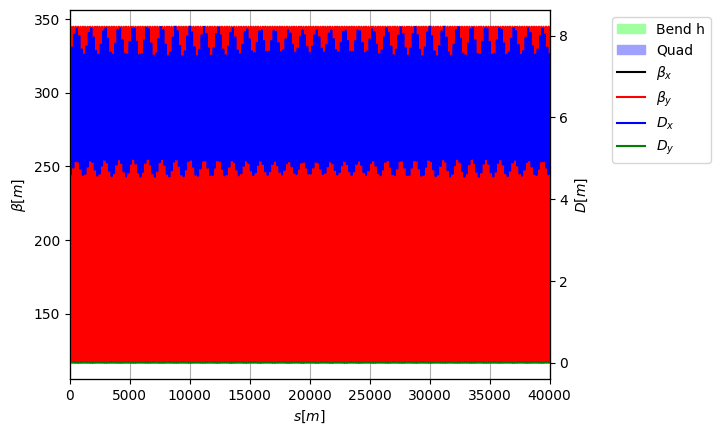

In [135]:

# ----------------------------------------------------------
# 7) Turn On Radiation
# ----------------------------------------------------------

ring.configure_radiation(model='mean')
ring.compensate_radiation_energy_loss()

tw6 = ring.twiss(method='6d', eneloss_and_damping=True)

print("\n--- 6D WITH RADIATION ---")

# Radiation integrals
print(tw6['eneloss_turn']) #provides the energy loss per turn (in eV).
print(tw6['damping_constants_s']) #provides the damping constants in x, y and zeta.
print(tw6['partition_numbers']) #provides the corresponding damping partion numbers.
print(tw6['eq_nemitt_x']) #provides the equilibrium horizontal emittance.
print(tw6['eq_nemitt_y']) #provides the equilibrium vertical emittance.
print(tw6['eq_nemitt_zeta']) #provides the equilibrium longitudinal emittance.

# ----------------------------------------------------------
# 8) Spin Tune Estimate
# ----------------------------------------------------------

a_e = 0.001159652
gamma = ring.particle_ref.gamma0[0]
nu_s = a_e * gamma

print("\n--- SPIN ---")
print("Gamma =", gamma)
print("Spin tune νs =", nu_s)

# ----------------------------------------------------------
# 9) Plot Beta and Dispersion
# ----------------------------------------------------------

tw6.plot()
plt.show()
